In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
BASERESULTSDIR = Path("example_results/")

In [3]:
resultsdirs_algos = {
    "Ewald": BASERESULTSDIR / "ewald_target-accuracy-0.001",
    "PME": BASERESULTSDIR / "pme_target-accuracy-0.001",
    "MSM": BASERESULTSDIR / "msm_target-accuracy-0.001",
}

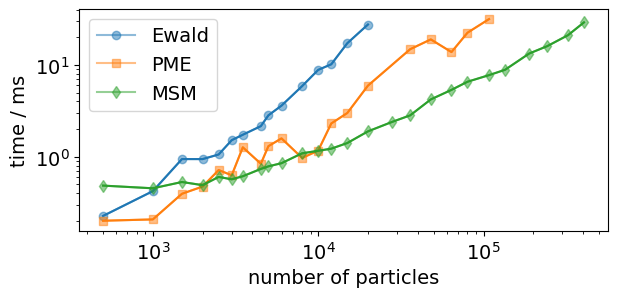

In [4]:
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
markers = ["o", "s", "d"]
plt.rcParams["font.size"] = 14
FIGSIZE = (6.4, 3.2)

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.set_xlabel("number of particles")
ax.set_ylabel("time / ms")
ax.set_xscale("log")
ax.set_yscale("log")
for m, c, (algo, resultsdir) in zip(
    markers, default_colors, resultsdirs_algos.items()
):
    df = pd.read_csv(resultsdir / "results.csv")
    ax.plot(df["n_particles"], df["time"] * 10**3, color=c)
    ax.plot(
        df["n_particles"],
        df["time"] * 10**3,
        color=c,
        marker=m,
        alpha=0.5,
        label=algo,
    )
ax.legend()
fig.tight_layout()
plt.show()

fig.savefig(BASERESULTSDIR / "comparative_algorithm_benchmark.pdf")